<a href="https://colab.research.google.com/github/Rehnoor-Aulakh/DL-Lab-Project/blob/main/VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split train → train + validation
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size

trainset, valset = torch.utils.data.random_split(full_trainset, [train_size, val_size])

100%|██████████| 170M/170M [00:05<00:00, 32.3MB/s]


**VGG MODEL**

In [3]:
class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256*4*4, 512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [4]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()

    return 100 * correct / total

In [5]:
def train_model(model, trainloader, valloader, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {
        "train_loss": [],
        "val_acc": [],
        "time": []
    }

    for epoch in range(epochs):
        model.train()
        start = time.time()
        running_loss = 0.0

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_time = time.time() - start
        val_acc = evaluate(model, valloader)

        history["train_loss"].append(running_loss)
        history["val_acc"].append(val_acc)
        history["time"].append(epoch_time)

        print(f"Epoch {epoch+1}: Loss={running_loss:.3f}, ValAcc={val_acc:.2f}, Time={epoch_time:.2f}s")

    return history

In [6]:
def get_loader(dataset, batch_size=128, shuffle=True):
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

val_loader = get_loader(valset, shuffle=False)
test_loader = get_loader(testset, shuffle=False)

**STRATEGY 1: FULL DATASET**

In [7]:
model_full = VGG().to(device)

train_loader_full = get_loader(trainset)

history_full = train_model(model_full, train_loader_full, val_loader, epochs=15)

test_acc_full = evaluate(model_full, test_loader)
print("Final Test Accuracy (Full):", test_acc_full)

Epoch 1: Loss=560.178, ValAcc=46.21, Time=24.53s
Epoch 2: Loss=419.261, ValAcc=55.93, Time=23.65s
Epoch 3: Loss=347.606, ValAcc=62.56, Time=23.24s
Epoch 4: Loss=303.925, ValAcc=68.31, Time=23.28s
Epoch 5: Loss=271.447, ValAcc=71.74, Time=25.17s
Epoch 6: Loss=242.346, ValAcc=72.65, Time=23.89s
Epoch 7: Loss=219.739, ValAcc=75.46, Time=24.24s
Epoch 8: Loss=203.500, ValAcc=78.00, Time=24.68s
Epoch 9: Loss=189.872, ValAcc=79.22, Time=25.48s
Epoch 10: Loss=178.488, ValAcc=79.89, Time=24.84s
Epoch 11: Loss=169.754, ValAcc=81.51, Time=23.56s
Epoch 12: Loss=159.309, ValAcc=80.32, Time=23.54s
Epoch 13: Loss=148.741, ValAcc=81.97, Time=24.09s
Epoch 14: Loss=145.467, ValAcc=82.22, Time=23.32s
Epoch 15: Loss=140.028, ValAcc=82.68, Time=23.62s
Final Test Accuracy (Full): 81.55


**STRATEGY 2: PROGRESSIVE DATASET REVELATION**

In [8]:
def get_subset(dataset, percentage):
    size = int(len(dataset) * percentage)
    indices = torch.randperm(len(dataset))[:size]
    return torch.utils.data.Subset(dataset, indices)

In [9]:
model_prog = VGG().to(device)

percentages = [0.1, 0.25, 0.5, 0.75, 1.0]
history_prog = {"train_loss": [], "val_acc": [], "time": []}

for p in percentages:
    print(f"\nTraining with {int(p*100)}% data")

    subset = get_subset(trainset, p)
    loader = get_loader(subset)

    h = train_model(model_prog, loader, val_loader, epochs=3)

    history_prog["train_loss"] += h["train_loss"]
    history_prog["val_acc"] += h["val_acc"]
    history_prog["time"] += h["time"]

test_acc_prog = evaluate(model_prog, test_loader)
print("Final Test Accuracy (Progressive):", test_acc_prog)


Training with 10% data
Epoch 1: Loss=71.448, ValAcc=21.23, Time=2.34s
Epoch 2: Loss=66.379, ValAcc=28.03, Time=2.75s
Epoch 3: Loss=62.841, ValAcc=30.42, Time=2.38s

Training with 25% data
Epoch 1: Loss=146.573, ValAcc=36.93, Time=6.10s
Epoch 2: Loss=133.143, ValAcc=38.69, Time=6.32s
Epoch 3: Loss=125.806, ValAcc=43.36, Time=6.33s

Training with 50% data
Epoch 1: Loss=226.671, ValAcc=50.37, Time=11.89s
Epoch 2: Loss=202.246, ValAcc=56.28, Time=11.90s
Epoch 3: Loss=186.694, ValAcc=59.55, Time=11.68s

Training with 75% data
Epoch 1: Loss=252.053, ValAcc=64.75, Time=17.37s
Epoch 2: Loss=222.198, ValAcc=68.09, Time=17.58s
Epoch 3: Loss=202.414, ValAcc=71.12, Time=17.66s

Training with 100% data
Epoch 1: Loss=250.562, ValAcc=73.15, Time=23.65s
Epoch 2: Loss=226.490, ValAcc=74.50, Time=23.27s
Epoch 3: Loss=210.156, ValAcc=76.96, Time=23.74s
Final Test Accuracy (Progressive): 76.69


**STRATEGY 3: CURRICULUM LEARNING (CORRECT)**

In [10]:
def compute_losses(model, dataset):
    loader = get_loader(dataset, shuffle=False)
    model.eval()
    losses = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = F.cross_entropy(out, y, reduction='none')
            losses.extend(loss.cpu().numpy())

    return losses

In [11]:
model_curr = VGG().to(device)

# Step 1: Warmup
train_loader = get_loader(trainset)
train_model(model_curr, train_loader, val_loader, epochs=3)

# Step 2: Compute difficulty
losses = compute_losses(model_curr, trainset)
indices = sorted(range(len(losses)), key=lambda i: losses[i])

curriculum_data = torch.utils.data.Subset(trainset, indices)

# Step 3: Train on sorted data
curr_loader = get_loader(curriculum_data, shuffle=False)

history_curr = train_model(model_curr, curr_loader, val_loader, epochs=12)

test_acc_curr = evaluate(model_curr, test_loader)
print("Final Test Accuracy (Curriculum):", test_acc_curr)

Epoch 1: Loss=577.832, ValAcc=43.26, Time=23.15s
Epoch 2: Loss=443.483, ValAcc=56.09, Time=23.28s
Epoch 3: Loss=367.837, ValAcc=63.45, Time=23.30s
Epoch 1: Loss=255.812, ValAcc=33.63, Time=23.36s
Epoch 2: Loss=238.824, ValAcc=37.95, Time=23.55s
Epoch 3: Loss=216.945, ValAcc=37.37, Time=23.43s
Epoch 4: Loss=205.903, ValAcc=43.26, Time=22.60s
Epoch 5: Loss=193.781, ValAcc=42.00, Time=23.43s
Epoch 6: Loss=181.826, ValAcc=48.55, Time=23.22s
Epoch 7: Loss=175.352, ValAcc=46.35, Time=23.42s
Epoch 8: Loss=166.286, ValAcc=48.53, Time=22.95s
Epoch 9: Loss=161.211, ValAcc=46.92, Time=23.42s
Epoch 10: Loss=153.092, ValAcc=50.84, Time=23.07s
Epoch 11: Loss=148.680, ValAcc=51.03, Time=23.23s
Epoch 12: Loss=141.122, ValAcc=49.86, Time=23.16s
Final Test Accuracy (Curriculum): 49.75


**Visualization**

In [12]:
def plot_history(h1, h2, h3):
    plt.figure()
    plt.plot(h1["train_loss"], label="Full")
    plt.plot(h2["train_loss"], label="Progressive")
    plt.plot(h3["train_loss"], label="Curriculum")
    plt.legend()
    plt.title("Training Loss")
    plt.show()

    plt.figure()
    plt.plot(h1["val_acc"], label="Full")
    plt.plot(h2["val_acc"], label="Progressive")
    plt.plot(h3["val_acc"], label="Curriculum")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.show()

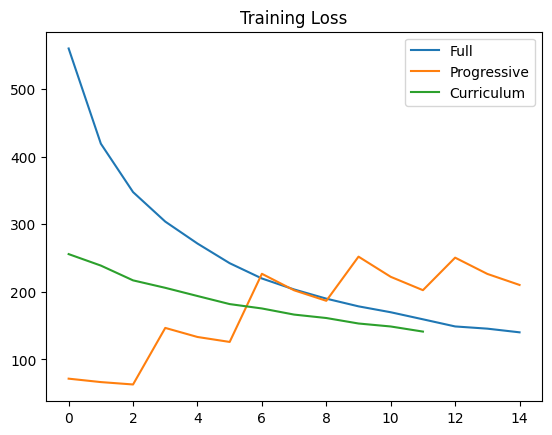

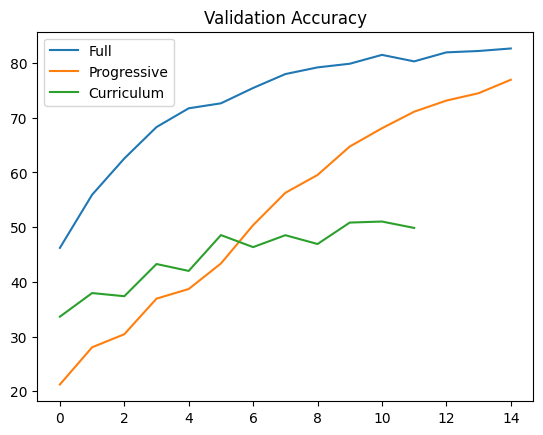

In [13]:
plot_history(history_full, history_prog, history_curr)